Loaded 120 graphs
ALE FEATURE IMPORTANCE ANALYSIS

Calculating ALE feature importance...
  Processing: Betweenness
  Processing: Closeness
  Processing: Clustering Coefficient
  Processing: Conductance
  Processing: Cut Ratio
  Processing: Degree
  Processing: E In
  Processing: E In Over E Out
  Processing: E Out
  Processing: Eigenvector
  Processing: Expansion
  Processing: Normalised Cut
  Processing: ODF
  Processing: Shortest Path
  Processing: Triangle Participation

ALE FEATURE IMPORTANCE RESULTS:
               feature  importance_mean  importance_median  ci_lower  ci_upper  n_graphs
             Expansion         0.169643           0.169680  0.160053  0.180053     120.0
Triangle Participation         0.148034           0.148148  0.134334  0.160277     120.0
           Eigenvector         0.103651           0.103821  0.090275  0.117330     120.0
Clustering Coefficient         0.086094           0.086325  0.077395  0.095954     120.0
             Cut Ratio         0.074347     

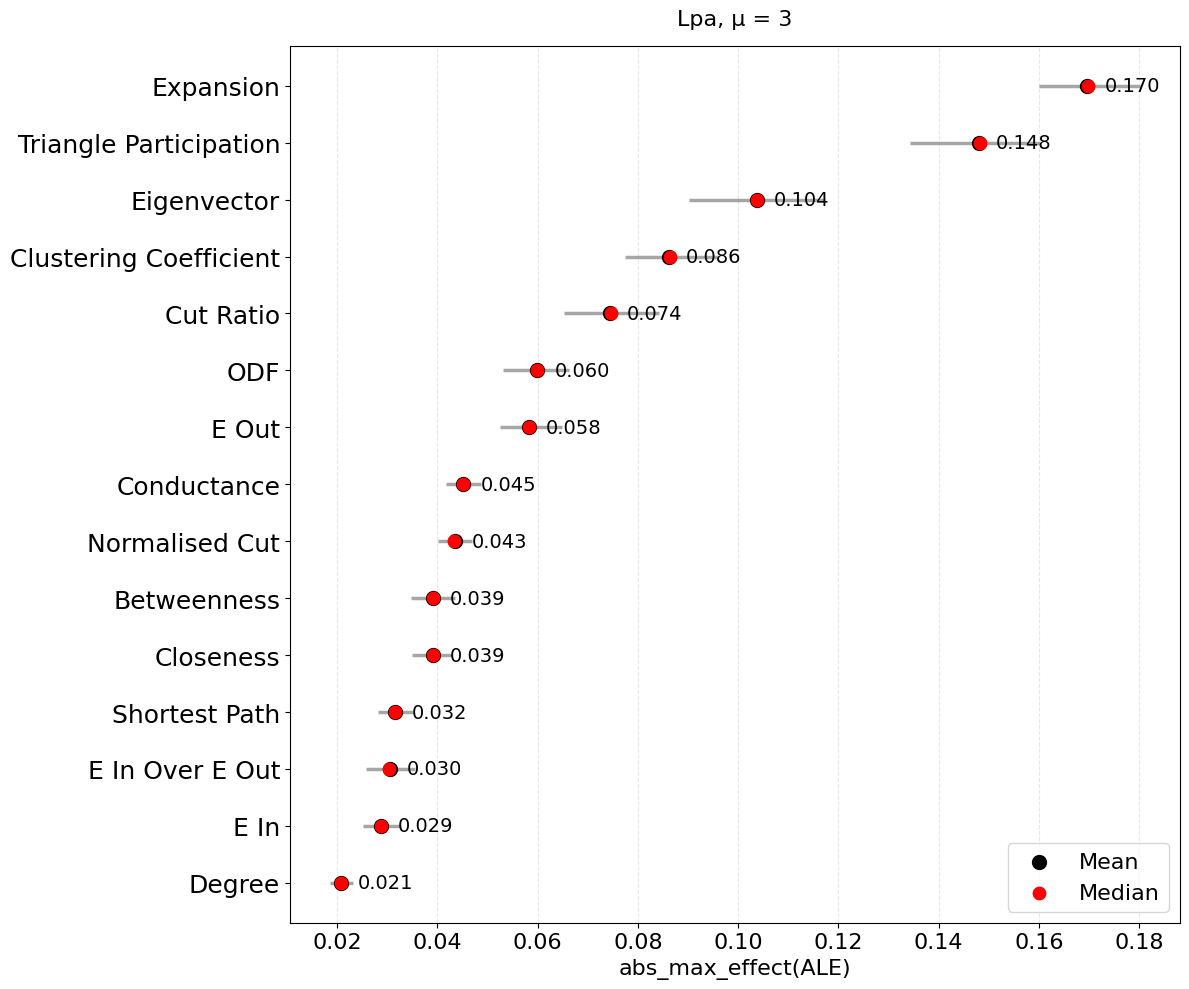


Analysis complete!


In [12]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import os
from scipy import interpolate

# ============================================
# CONFIGURAÇÃO
# ============================================
mi = 3# ou 2, 3, etc.
mu = f'mu_0_{mi}'
algorithm = 'lpa'  # ou 'lpa'

# Carregar resultados
results_path = f'LFR_Graph_Data/Community_Data/{algorithm}/results/{mu}/all_graphs_results.pkl'
with open(results_path, 'rb') as f:
    all_results = pickle.load(f)

print(f"Loaded {len(all_results)} graphs")

# ============================================
# FUNÇÃO PARA CALCULAR ALE FEATURE IMPORTANCE
# ============================================

def calculate_ale_feature_importance(all_results, feature_names=None, n_bootstrap=1000, random_state=42):
    """
    Calcula feature importance baseado em ALE (Accumulated Local Effects).
    
    A importância é medida pelo valor máximo absoluto da curva ALE,
    que indica o impacto máximo da feature na predição.
    
    Returns:
        DataFrame com importâncias e intervalos de confiança
    """
    np.random.seed(random_state)
    
    # Definir features se não fornecidas
    if feature_names is None:
        feature_names = set()
        for results in all_results.values():
            if 'ale_curves' in results:
                feature_names.update(results['ale_curves'].keys())
        feature_names = sorted(feature_names)
    
    importance_results = {}
    
    for feature in feature_names:
        print(f"  Processing: {feature}")
        
        # Coletar valores de importância máxima para este feature
        max_abs_effects = []
        
        for graph_name, results in all_results.items():
            if 'ale_curves' in results and feature in results['ale_curves']:
                df = results['ale_curves'][feature]
                # Importância = máximo valor absoluto da curva ALE
                max_abs_effect = np.max(np.abs(df['ale_mean'].values))
                max_abs_effects.append(max_abs_effect)
        
        if not max_abs_effects:
            continue
        
        # Bootstrap para intervalo de confiança
        bootstrap_means = []
        
        for _ in range(n_bootstrap):
            bootstrap_sample = np.random.choice(max_abs_effects, 
                                                size=len(max_abs_effects), 
                                                replace=True)
            bootstrap_means.append(np.mean(bootstrap_sample))
        
        # Calcular estatísticas
        importance_results[feature] = {
            'importance_mean': np.mean(max_abs_effects),
            'importance_median': np.median(bootstrap_means),
            'ci_lower': np.percentile(bootstrap_means, 2.5),
            'ci_upper': np.percentile(bootstrap_means, 97.5),
            'std_effect': np.std(max_abs_effects),
            'n_graphs': len(max_abs_effects)
        }
    
    # Converter para DataFrame
    df_importance = pd.DataFrame(importance_results).T
    df_importance.index.name = 'feature'
    df_importance = df_importance.reset_index()
    
    # Ordenar por importância (maior primeiro)
    df_importance = df_importance.sort_values('importance_mean', ascending=False)
    
    return df_importance


# ============================================
# FUNÇÃO PARA PLOTAR ALE FEATURE IMPORTANCE
# ============================================

def plot_ale_feature_importance(df_importance, algorithm, mu, output_dir=None):
    """
    Plota feature importance baseado em ALE no estilo da imagem:
    - Ponto preto = média
    - Ponto vermelho = mediana  
    - Linhas = intervalo de confiança 95% bootstrapped
    """
    if output_dir is None:
        output_dir = f'Resultados/ale_feature_importance/{algorithm}/{mu}/'
    os.makedirs(output_dir, exist_ok=True)
    
    # Configurar estilo
    plt.style.use('default')
    
    fig, ax = plt.subplots(figsize=(12, 10))
    
    # Preparar dados
    features = df_importance['feature'].values
    means = df_importance['importance_mean'].values
    medians = df_importance['importance_median'].values
    ci_lower = df_importance['ci_lower'].values
    ci_upper = df_importance['ci_upper'].values
    
    # Posições y para cada feature (invertido para ter o mais importante em cima)
    y_pos = np.arange(len(features))
    
    # Plotar intervalos de confiança (linhas horizontais)
    for i, (low, high) in enumerate(zip(ci_lower, ci_upper)):
        ax.hlines(y=y_pos[i], xmin=low, xmax=high, 
                  colors='gray', linewidth=2.5, alpha=0.7)
    
    # Plotar pontos da média (preto)
    ax.scatter(means, y_pos, color='black', s=100, zorder=5, 
               label='Mean', marker='o')
    
    # Plotar pontos da mediana (vermelho)
    ax.scatter(medians, y_pos, color='red', s=80, zorder=6,
               label='Median', marker='o')
    
    # Configurar eixo ys
    ax.set_yticks(y_pos)
    ax.set_yticklabels(features, fontsize=18)
    ax.invert_yaxis()  # Maior importância em cima
    
    # Configurar eixo x
    ax.set_xlabel('abs_max_effect(ALE)', fontsize=16)
    plt.xticks(fontsize=16)
    
    # Adicionar grid
    ax.grid(True, axis='x', alpha=0.3, linestyle='--')
    
    # Adicionar legenda
    ax.legend(loc='lower right', fontsize=16)
    
    # Título
    mu_value = mu.replace('mu_0_', '')
    ax.set_title(f'{algorithm.capitalize()}, μ = {mu_value}', 
                 fontsize=16, pad=15)
    
    # Adicionar anotações com valores
    for i, (mean, median) in enumerate(zip(means, medians)):
        ax.annotate(f'{mean:.3f}', 
                   xy=(mean + 0.002, i), 
                   xytext=(5, 0), 
                   textcoords='offset points',
                   fontsize=14, ha='left', va='center')
    
    # Ajustar layout
    plt.tight_layout()
    
    # Salvar figura
    filename = f'ale_feature_importance_{algorithm}_{mu}.png'
    filepath = os.path.join(output_dir, filename)
    plt.savefig(filepath, dpi=300, bbox_inches='tight')
    print(f"\nSaved to: {filepath}")
    
    # Também salvar em PDF
    pdf_path = os.path.join(output_dir, f'ale_feature_importance_{algorithm}_{mu}.pdf')
    plt.savefig(pdf_path, bbox_inches='tight')
    
    plt.show()
    
    return fig, ax


# ============================================
# PLOTAR VERSÃO COM MÚLTIPLOS SUBPLOTS
# ============================================

def plot_ale_feature_importance_multi(results_dict, fig_title="ALE Feature Importance Comparison"):
    """
    Plota ALE feature importance para múltiplos algoritmos/parâmetros em subplots.
    
    results_dict: dict com chaves como ('louvain', 'mu_0_2') e valores como df_importance
    """
    n_plots = len(results_dict)
    n_cols = min(2, n_plots)
    n_rows = (n_plots + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 6 * n_rows))
    if n_plots == 1:
        axes = [axes]
    else:
        axes = axes.flatten()
    
    for idx, ((algo, mu_label), df_imp) in enumerate(results_dict.items()):
        ax = axes[idx]
        
        features = df_imp['feature'].values
        means = df_imp['importance_mean'].values
        medians = df_imp['importance_median'].values
        ci_lower = df_imp['ci_lower'].values
        ci_upper = df_imp['ci_upper'].values
        y_pos = np.arange(len(features))
        
        # Intervalos de confiança
        for i, (low, high) in enumerate(zip(ci_lower, ci_upper)):
            ax.hlines(y=y_pos[i], xmin=low, xmax=high, 
                      colors='gray', linewidth=2, alpha=0.7)
        
        # Pontos
        ax.scatter(means, y_pos, color='black', s=90, zorder=5, marker='o')
        ax.scatter(medians, y_pos, color='red', s=70, zorder=6, marker='o')
        
        # Labels
        ax.set_yticks(y_pos)
        ax.set_yticklabels(features, fontsize=12)
        ax.invert_yaxis()
        ax.set_xlabel('abs_max_effect(ALE)', fontsize=10)
        ax.grid(True, axis='x', alpha=0.3, linestyle='--')
        
        # Título
        mu_value = mu_label.replace('mu_0_', '')
        ax.set_title(f'{algo.capitalize()}, μ = {mu_value}', fontsize=14, fontweight='bold')
    
    # Ocultar subplots não utilizados
    for idx in range(len(results_dict), len(axes)):
        axes[idx].set_visible(False)
    
    # Legenda global
    fig.legend(['95% CI', 'Mean', 'Median'], loc='lower right', fontsize=11)
    
    # Título geral
    fig.suptitle(fig_title, fontsize=18, y=1.02)
    
    plt.tight_layout()
    
    # Salvar
    output_dir = 'Resultados/ale_feature_importance/comparison/'
    os.makedirs(output_dir, exist_ok=True)
    plt.savefig(os.path.join(output_dir, 'ale_feature_importance_comparison.png'), 
                dpi=300, bbox_inches='tight')
    plt.show()
    
    return fig, axes


# ============================================
# EXECUÇÃO PRINCIPAL
# ============================================

print("=" * 60)
print("ALE FEATURE IMPORTANCE ANALYSIS")
print("=" * 60)

# Calcular ALE feature importance
print("\nCalculating ALE feature importance...")
df_importance = calculate_ale_feature_importance(all_results)

# Mostrar resultados
print("\n" + "=" * 60)
print("ALE FEATURE IMPORTANCE RESULTS:")
print("=" * 60)
print(df_importance[['feature', 'importance_mean', 'importance_median', 
                      'ci_lower', 'ci_upper', 'n_graphs']].to_string(index=False))

# Salvar CSV
output_dir = f'Resultados/ale_feature_importance/{algorithm}/{mu}/'
os.makedirs(output_dir, exist_ok=True)
csv_path = os.path.join(output_dir, f'ale_feature_importance_{algorithm}_{mu}.csv')
df_importance.to_csv(csv_path, index=False)
print(f"\nCSV saved to: {csv_path}")

# Plotar
print("\nPlotting ALE feature importance...")
plot_ale_feature_importance(df_importance, algorithm, mu)

# ============================================
# OPCIONAL: Plotar comparação entre diferentes μ
# ============================================

def load_multiple_mus_ale(algorithm='louvain', mu_list=[2, 3, 4]):
    """Carrega resultados ALE para múltiplos valores de μ"""
    results_dict = {}
    
    for mi in mu_list:
        mu_label = f'mu_0_{mi}'
        try:
            results_path = f'LFR_Graph_Data/Community_Data/{algorithm}/results/{mu_label}/all_graphs_results.pkl'
            with open(results_path, 'rb') as f:
                all_results = pickle.load(f)
            
            df_imp = calculate_ale_feature_importance(all_results)
            results_dict[(algorithm, mu_label)] = df_imp
            print(f"Loaded {algorithm}, {mu_label}: {len(df_imp)} features")
        except FileNotFoundError:
            print(f"File not found for {algorithm}, {mu_label}")
    
    return results_dict


# Descomente para usar:
# print("\nLoading multiple μ values...")
# results_dict = load_multiple_mus_ale(algorithm='louvain', mu_list=[2, 3, 4])
# plot_ale_feature_importance_multi(results_dict, fig_title="ALE Feature Importance - Louvain")

print("\n" + "=" * 60)
print("Analysis complete!")
print("=" * 60)